In [4]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import integrate as integrate
import pandas as pd

def rhoNFW(r,r_s,rho_s):
    rhoNFW = rho_s * (r_s/r) * (1. + r/r_s)**(-2)
    return rhoNFW

def rhoEin(r,r_s,rho_s,alpha):
    rhoEin = rho_s * np.exp(-(2./alpha) * ((r/r_s)**alpha - 1.))
    return rhoEin

def rhoIso(r,r_s,rho_s):
    rhoIso = rho_s/(1. + (r/r_s)**2)    
    return rhoIso

def rhoBur(r,r_s,rho_s): 
    rhoBur = rho_s/((1. + r/r_s) * (1. + (r/r_s)**2))    
    return rhoBur

def rhoMoo(r,r_s,rho_s):
    rhoMoo = rho_s * (r_s/r)**1.16 * (1. + r/r_s)**(-1.84)    
    return rhoMoo



# rs [kpc] rho [GeV/cm3]
#NFW 􀀀 24.42 0.184
#Einasto 0.17 28.44 0.033
#EinastoB 0.11 35.24 0.021
#Isothermal 􀀀 4.38 1.387
#Burkert 􀀀 12.67 0.712
#Moore 􀀀 30.28 0.105
[rs_1, rho_1, 
 rs_2, rho_2, 
 rs_3, rho_3, 
 rs_4, rho_4, 
 rs_5, rho_5, 
 rs_6, rho_6] = [24.42, 0.184,
  28.44, 0.033,
  35.24, 0.021,
4.38, 1.387,
12.67, 0.712,
 30.28, 0.105] 
[alpha_1, alpha_2] = [0.17, 0.11]
[rs_CTA, rho_CTA] = [20,0.081]

r_Sun = 8.33
rho_Sun = 0.3

kpc_cm = 3.086e21 # kpc/cm



In [5]:
########################
# NFW profile
from scipy.interpolate import interp1d as interp1d

s_int = np.logspace(-4,2.3,100000)

#theta = np.logspace(-10,-3,1000) + np.linspace(1e-10, np.pi, 1000)
theta = np.logspace(-10,np.log10(np.pi+1e-10), 1000)

def rhoNFW_int(s,theta):
  rhoNFW_int = rhoNFW(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_1,rho_1)
  return rhoNFW_int

def rhoNFW_int2(s,theta):
  rhoNFW_int2 = rhoNFW_int(s,theta)**2
  return rhoNFW_int2

def J_NFW_ann(theta):
  J_NFW = integrate.trapezoid(rhoNFW_int2(s_int,theta), s_int) / (r_Sun*rho_Sun**2)
  #J_NFW = integrate.quad(rhoNFW_int2,0, 200, args = (theta))[0] / (r_Sun*rho_Sun**2)
  return J_NFW
J_NFW_ann = np.vectorize(J_NFW_ann)
J_NFW_ann = interp1d(theta, J_NFW_ann(theta))

def J_NFW_dec(theta):
  J_NFW = integrate.trapezoid(rhoNFW_int(s_int,theta), s_int) / (r_Sun*rho_Sun)
  #J_NFW = integrate.quad(rhoNFW_int,0, 200, args = (theta))[0] / (r_Sun*rho_Sun)
  return J_NFW
J_NFW_dec = np.vectorize(J_NFW_dec)
J_NFW_dec = interp1d(theta, J_NFW_dec(theta))




################################
# Usual Einasto profile





def rhoEin_int(s,theta):
  rhoEin_int = rhoEin(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_2,rho_2,alpha_1)
  return rhoEin_int 

def rhoEin_int2(s,theta):
  rhoEin_int2 = rhoEin_int(s,theta)**2
  return rhoEin_int2

def J_Ein_ann(theta):
  J_Ein = integrate.trapezoid(rhoEin_int2(s_int,theta), s_int) / (r_Sun*rho_Sun**2)
  return J_Ein
J_Ein_ann = np.vectorize(J_Ein_ann)
J_Ein_ann = interp1d(theta, J_Ein_ann(theta))

def J_Ein_dec(theta):
  J_Ein = integrate.trapezoid(rhoEin_int(s_int,theta), s_int) / (r_Sun*rho_Sun)
  return J_Ein
J_Ein_dec = np.vectorize(J_Ein_dec)  
J_Ein_dec = interp1d(theta, J_Ein_dec(theta))




################################
# Modified Einasto profile





def rhoEinB_int(s,theta):
  rhoEinB_int = rhoEin(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_3,rho_3,alpha_2)
  return rhoEinB_int 

def rhoEinB_int2(s,theta):
  rhoEinB_int2 = rhoEinB_int(s,theta)**2
  return rhoEinB_int2

def J_EinB_ann(theta):
  J_EinB = integrate.trapezoid(rhoEinB_int2(s_int,theta), s_int) / (r_Sun*rho_Sun**2)
  return J_EinB
J_EinB_ann = np.vectorize(J_EinB_ann)
J_EinB_ann = interp1d(theta, J_EinB_ann(theta))

def J_EinB_dec(theta):
  J_EinB = integrate.trapezoid(rhoEinB_int(s_int,theta), s_int) / (r_Sun*rho_Sun)
  return J_EinB
J_EinB_dec = np.vectorize(J_EinB_dec)
J_EinB_dec = interp1d(theta, J_EinB_dec(theta))




################################
# Isotermal profile





def rhoIso_int(s,theta):
  rhoIso_int = rhoIso(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_4,rho_4)
  return rhoIso_int

def rhoIso_int2(s,theta):
  rhoIso_int2 = rhoIso_int(s,theta)**2
  return rhoIso_int2

def J_Iso_ann(theta):
  J_Iso = integrate.trapezoid(rhoIso_int2(s_int,theta), s_int) / (r_Sun*rho_Sun**2)
  return J_Iso
J_Iso_ann = np.vectorize(J_Iso_ann)
J_Iso_ann = interp1d(theta, J_Iso_ann(theta))

def J_Iso_dec(theta):
  J_Iso = integrate.trapezoid(rhoIso_int(s_int,theta), s_int) / (r_Sun*rho_Sun)
  return J_Iso
J_Iso_dec = np.vectorize(J_Iso_dec)  
J_Iso_dec = interp1d(theta, J_Iso_dec(theta))


################################
# Burket profile





def rhoBur_int(s,theta):
  rhoBur_int = rhoBur(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_5,rho_5)
  return rhoBur_int

def rhoBur_int2(s,theta):
  rhoBur_int2 = rhoBur_int(s,theta)**2
  return rhoBur_int2

def J_Bur_ann(theta):
  J_Bur = integrate.trapezoid(rhoBur_int2(s_int,theta), s_int) / (r_Sun*rho_Sun**2)
  return J_Bur
J_Bur_ann = np.vectorize(J_Bur_ann)
J_Bur_ann = interp1d(theta, J_Bur_ann(theta))

def J_Bur_dec(theta):
  J_Bur = integrate.trapezoid(rhoBur_int(s_int,theta), s_int) / (r_Sun*rho_Sun)
  return J_Bur
J_Bur_dec = np.vectorize(J_Bur_dec)  
J_Bur_dec = interp1d(theta, J_Bur_dec(theta))




################################
# Moore profile





def rhoMoo_int(s,theta):
  rhoMoo_int = rhoMoo(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_6,rho_6)
  return rhoMoo_int

def rhoMoo_int2(s,theta):
  rhoMoo_int2 = rhoMoo_int(s,theta)**2
  return rhoMoo_int2

def J_Moo_ann(theta):
  J_Moo = integrate.trapezoid(rhoMoo_int2(s_int,theta), s_int) / (r_Sun*rho_Sun**2)
  return J_Moo
J_Moo_ann = np.vectorize(J_Moo_ann)
J_Moo_ann = interp1d(theta, J_Moo_ann(theta))

def J_Moo_dec(theta):
  J_Moo = integrate.trapezoid(rhoMoo_int(s_int,theta), s_int) / (r_Sun*rho_Sun)
  return J_Moo
J_Moo_dec = np.vectorize(J_Moo_dec)  
J_Moo_dec = interp1d(theta, J_Moo_dec(theta))


Text(0.5, 1.0, '$J$-factor evalutation for decay')

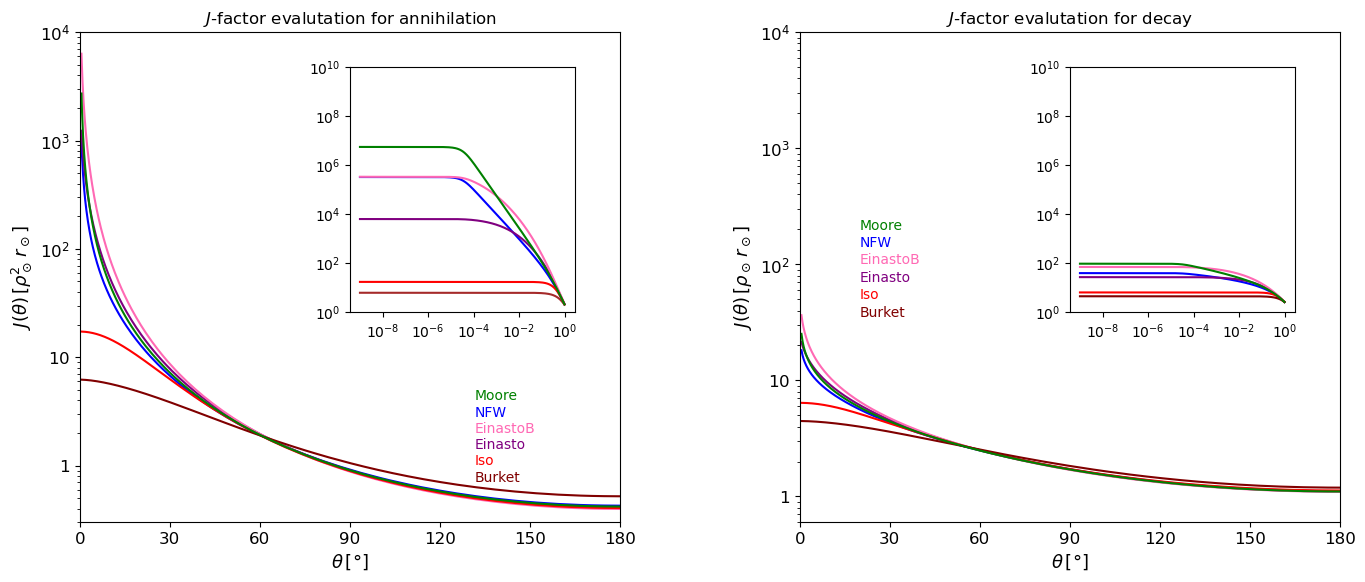

In [7]:
fig = plt.figure(figsize= (18,7))
ax1 = fig.add_axes([0.1, 0.1, 0.3, 0.7])
ax2 = fig.add_axes([0.5, 0.1, 0.3, 0.7])
ax12 = fig.add_axes([0.25, 0.4, 0.125, 0.35])
#[0.25, 0.5, 0.125, 0.25]
ax22 = fig.add_axes([0.65, 0.4, 0.125, 0.35])

# (20, 8)
t = np.linspace(1e-2, np.pi, 1000)
#t = np.linspace(1e-2, np.pi/18., 1000)
#t = np.logspace(-2, np.log10(np.pi), 1000)
#print(t[-1])

ax1.set_yscale('log')
ax1.set_xlim(0,np.pi)
#ax1.set_xlim(0,np.pi/18.)
ax1.set_ylim(.3,1e4)
ax1.plot(t, J_NFW_ann(t), '-b')
ax1.plot(t, J_Ein_ann(t), color = 'purple', linestyle='solid')
ax1.plot(t, J_EinB_ann(t), color = 'hotpink')
ax1.plot(t, J_Iso_ann(t), color = 'r')
ax1.plot(t, J_Bur_ann(t), color = 'maroon')
ax1.plot(t, J_Moo_ann(t), color = 'green')
ax1.set_xticks(np.pi*np.arange(0.,1.16,1/6))
ax1.set_xticklabels(['0','30','60','90','120','150','180'],fontsize=12)
ax1.set_xlabel(r'$\theta \,[°]$',fontsize=13)
ax1.set_yticks([1,1e1,1e2,1e3,1e4])
ax1.set_yticklabels([r'$1$',r'$10$',r'$10^2$',r'$10^3$',r'$10^4$'],fontsize=12)
ax1.set_ylabel(r'$ J (\theta) \, [\rho_\odot^2 \, r_\odot]$ ',fontsize=13)
#ax11 = ax1.twinx()
#ax11.set_yscale('log')
#ax11.set_ylim(.3,1e3)
#ax11.set_ylabel('')
#ax11.set_yticklabels('')

ax1.text(2.3,4,r'Moore', color = 'green')
ax1.text(2.3,4*10**(-0.15),r'NFW', color = 'blue')
ax1.text(2.3,4*10**(-0.3),r'EinastoB', color = 'hotpink')
ax1.text(2.3,4*10**(-0.45),r'Einasto', color = 'purple')
ax1.text(2.3,4*10**(-0.60),r'Iso', color = 'red')
ax1.text(2.3,4*10**(-0.75),r'Burket', color = 'maroon')


t2 = np.logspace(-9,0,500) 

ax12.set_xscale('log')
ax12.set_yscale('log')
#ax12.set_xlim(1e-9,2.500)
ax12.set_ylim(1,1e10)
ax12.plot(t2, J_NFW_ann(t2), '-b')
ax12.plot(t2, J_Ein_ann(t2), color = 'purple', linestyle='solid')
ax12.plot(t2, J_EinB_ann(t2), color = 'hotpink')
ax12.plot(t2, J_Iso_ann(t2), color = 'r')
ax12.plot(t2, J_Bur_ann(t2), color = 'brown')
ax12.plot(t2, J_Moo_ann(t2), color = 'green')
ax12.set_xticks([1e-8,1e-6,1e-4,1e-2,1.])
ax12.set_yticks([1.,1e2,1e4,1e6,1e8,1e10])
#ax12.set_xticklabels([r'$$'])


####################################
# right plot

ax2.set_yscale('log')
ax2.set_xlim(0,np.pi)
#ax2.set_xlim(0,np.pi/18.)
ax2.set_ylim(.6,1e3)
ax2.plot(t, J_NFW_dec(t), '-b')
ax2.plot(t, J_Ein_dec(t), color = 'purple', linestyle='solid')
ax2.plot(t, J_EinB_dec(t), color = 'hotpink')
ax2.plot(t, J_Iso_dec(t), color = 'r')
ax2.plot(t, J_Bur_dec(t), color = 'maroon')
ax2.plot(t, J_Moo_dec(t), color = 'green')
ax2.set_xticks(np.pi*np.arange(0.,1.16,1/6))
ax2.set_xticklabels(['0','30','60','90','120','150','180'],fontsize=12)
ax2.set_xlabel(r'$\theta \,[°]$',fontsize=13)
ax2.set_yticks([1,1e1,1e2,1e3,1e4])
ax2.set_yticklabels([r'$1$',r'$10$',r'$10^2$',r'$10^3$',r'$10^4$'],fontsize=12)
ax2.set_ylabel(r'$ J (\theta) \, [\rho_\odot \, r_\odot]$ ',fontsize=13)
#ax21 = ax2.twinx()
#ax21.set_yscale('log')
#ax21.set_ylim(.3,1e3)
#ax21.set_ylabel('')
#ax21.set_yticklabels('')

ax2.text(0.35,200,r'Moore', color = 'green')
ax2.text(0.35,200*10**(-0.15),r'NFW', color = 'blue')
ax2.text(0.35,200*10**(-0.3),r'EinastoB', color = 'hotpink')
ax2.text(0.35,200*10**(-0.45),r'Einasto', color = 'purple')
ax2.text(0.35,200*10**(-0.60),r'Iso', color = 'red')
ax2.text(0.35,200*10**(-0.75),r'Burket', color = 'maroon')


ax22.set_xscale('log')
ax22.set_yscale('log')
#ax22.set_xlim(1e-9,2,500)
ax22.set_ylim(1,1e10)
ax22.plot(t2, J_NFW_dec(t2), '-b')
ax22.plot(t2, J_Ein_dec(t2), color = 'purple', linestyle='solid')
ax22.plot(t2, J_EinB_dec(t2), color = 'hotpink')
ax22.plot(t2, J_Iso_dec(t2), color = 'r')
ax22.plot(t2, J_Bur_dec(t2), color = 'maroon')
ax22.plot(t2, J_Moo_dec(t2), color = 'green')
ax22.set_xticks([1e-8,1e-6,1e-4,1e-2,1.])
ax22.set_yticks([1.,1e2,1e4,1e6,1e8,1e10])

ax1.set_title(r"$J$-factor evalutation for annihilation")
ax2.set_title(r"$J$-factor evalutation for decay")

#ax1.scatter(t[0],J_EinB_ann(t[0]))

#plt.savefig("Jfactor_curve.pdf")

In [5]:
[bmin, bmax] = [-1e1, 1e1]
[lmin, lmax] = [-1e1, 1e1]
[db, dl] = [2e-2, 2e-2]
b = np.arange(bmin, bmax + db, db)
l = np.arange(lmin, lmax + dl, dl)
nb = len(b)
nl = len(l)
b = b.reshape([nb, 1])
p = np.pi/180. # converts degrees to radians
[b_rad, l_rad] = [p*b, p*l]

th =  np.arccos(np.cos(b_rad)*np.cos(l_rad))
J = np.zeros([nb, nl, 12])
J_bar = np.zeros([nb, nl, 12])

#eliminar ângulos menores que < 1e-2 degrees
condition = th < (1e-2*p)
th[condition] = 1e-2*p
J[:,:,2] = J_NFW_ann(th)
J[:,:,3] = J_NFW_dec(th)
J[:,:,4] = J_Ein_ann(th)
J[:,:,5] = J_Ein_dec(th)
J[:,:,6] = J_EinB_ann(th)
J[:,:,7] = J_EinB_dec(th)
J[:,:,8] = J_Iso_ann(th)
J[:,:,9] = J_Iso_dec(th)
J[:,:,10] = J_Bur_ann(th)
J[:,:,11] = J_Bur_dec(th)
J[:,:,0] = J_Moo_ann(th)
J[:,:,1] = J_Moo_dec(th)

J_bar[:,:,0] = J[:,:,0]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,1] = J[:,:,1]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,2] = J[:,:,2]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,3] = J[:,:,3]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,4] = J[:,:,4]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,5] = J[:,:,5]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,6] = J[:,:,6]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,7] = J[:,:,7]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,8] = J[:,:,8]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,9] = J[:,:,9]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,10] = J[:,:,10]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,11] = J[:,:,11]*np.cos(b_rad)*np.ones(nl)


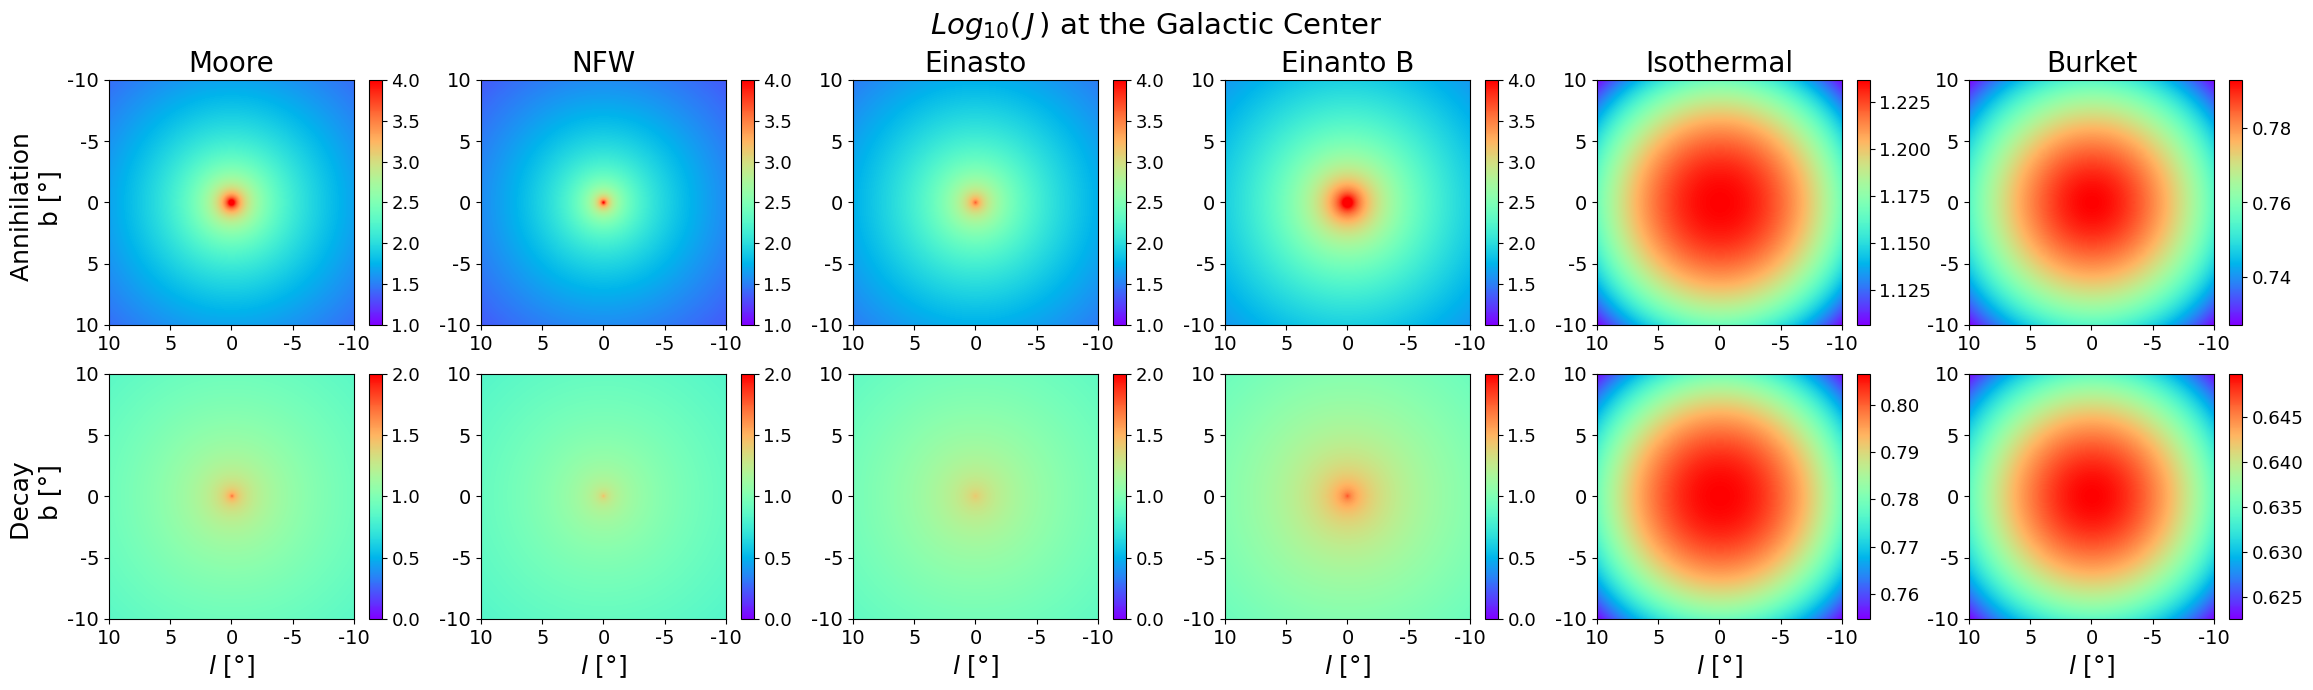

In [9]:
fig, axs = plt.subplots(2,6, figsize = (28,7)) 
cmap = 'rainbow'
im1 = axs[0,0].imshow(np.log10(J[:,:,0]), cmap = cmap, vmin = 1, vmax = 4,origin='lower',extent=(lmax,lmin,bmin,bmax))
im2 = axs[1,0].imshow(np.log10(J[:,:,1]), cmap = cmap, vmin = 0, vmax = 2,origin='lower',extent=(lmax,lmin,bmin,bmax))
im3 = axs[0,1].imshow(np.log10(J[:,:,2]), cmap = cmap, vmin = 1, vmax = 4,origin='lower',extent=(lmax,lmin,bmin,bmax))
im4 = axs[1,1].imshow(np.log10(J[:,:,3]), cmap = cmap, vmin = 0, vmax = 2,origin='lower',extent=(lmax,lmin,bmin,bmax))
im5 = axs[0,2].imshow(np.log10(J[:,:,4]), cmap = cmap, vmin = 1, vmax = 4,origin='lower',extent=(lmax,lmin,bmin,bmax))
im6 = axs[1,2].imshow(np.log10(J[:,:,5]), cmap = cmap, vmin = 0, vmax = 2,origin='lower',extent=(lmax,lmin,bmin,bmax))
im7 = axs[0,3].imshow(np.log10(J[:,:,6]), cmap = cmap, vmin = 1, vmax = 4,origin='lower',extent=(lmax,lmin,bmin,bmax))
im8 = axs[1,3].imshow(np.log10(J[:,:,7]), cmap = cmap, vmin = 0, vmax = 2, origin='lower',extent=(lmax,lmin,bmin,bmax))
im9 = axs[0,4].imshow(np.log10(J[:,:,8]), cmap = cmap, vmin = np.log10(np.min(J[:,:,8])), vmax = np.log10(np.max(J[:,:,8])),origin='lower',extent=(lmax,lmin,bmin,bmax))
im10 = axs[1,4].imshow(np.log10(J[:,:,9]), cmap = cmap, vmin = np.log10(np.min(J[:,:,9])), vmax = np.log10(np.max(J[:,:,9])),origin='lower',extent=(lmax,lmin,bmin,bmax))
im11 = axs[0,5].imshow(np.log10(J[:,:,10]), cmap = cmap, vmin = np.log10(np.min(J[:,:,10])), vmax = np.log10(np.max(J[:,:,10])),origin='lower',extent=(lmax,lmin,bmin,bmax))
im12 = axs[1,5].imshow(np.log10(J[:,:,11]), cmap = cmap, vmin = np.log10(np.min(J[:,:,11])), vmax = np.log10(np.max(J[:,:,11])),origin='lower',extent=(lmax,lmin,bmin,bmax))

fig.suptitle(r"$Log_{10}(\,J\,)$ at the Galactic Center",fontsize=21)

#axs[0,0].set_title("Annihilation")
#axs[0,1].set_title("Decay")
#axs[0,0].set_ylabel("NFW \n b [°]")
#axs[1,0].set_ylabel("Einasto \n b [°]")
#axs[2,0].set_ylabel("Einanto B \n b [°]")
#axs[3,0].set_ylabel("Isothermal \n b [°]")
#axs[4,0].set_ylabel("Burket \n b [°]")
#axs[5,0].set_ylabel("Moore \n b [°]")
#axs[5,0].set_xlabel(r"$l$ [°]")
#axs[5,1].set_xlabel(r"$l$ [°]")

#axs[0,0].set_title("")
#axs[0,1].set_title("")
axs[0,1].set_title("NFW",fontsize=20)
axs[0,2].set_title("Einasto",fontsize=20)
axs[0,3].set_title("Einanto B",fontsize=20)
axs[0,4].set_title("Isothermal",fontsize=20)
axs[0,5].set_title("Burket",fontsize=20)
axs[0,0].set_title("Moore",fontsize=20)

axs[0,0].set_ylabel("Annihilation \n b [°]",fontsize=18)
axs[1,0].set_ylabel("Decay \n b [°]",fontsize=18)

axs[1,0].set_xlabel(r"$l$ [°]",fontsize=18)
axs[1,1].set_xlabel(r"$l$ [°]",fontsize=18)
axs[1,2].set_xlabel(r"$l$ [°]",fontsize=18)
axs[1,3].set_xlabel(r"$l$ [°]",fontsize=18)
axs[1,4].set_xlabel(r"$l$ [°]",fontsize=18)
axs[1,5].set_xlabel(r"$l$ [°]",fontsize=18)


axs[0,0].set_xticks([-10,-5,0,5,10])
axs[0,1].set_xticks([-10,-5,0,5,10])
axs[0,2].set_xticks([-10,-5,0,5,10])
axs[0,3].set_xticks([-10,-5,0,5,10])
axs[0,4].set_xticks([-10,-5,0,5,10])
axs[0,5].set_xticks([-10,-5,0,5,10])
axs[1,0].set_xticks([-10,-5,0,5,10])
axs[1,1].set_xticks([-10,-5,0,5,10])
axs[1,2].set_xticks([-10,-5,0,5,10])
axs[1,3].set_xticks([-10,-5,0,5,10])
axs[1,4].set_xticks([-10,-5,0,5,10])
axs[1,5].set_xticks([-10,-5,0,5,10])

axs[0,0].set_yticks([-10,-5,0,5,10])
axs[0,1].set_yticks([-10,-5,0,5,10])
axs[0,2].set_yticks([-10,-5,0,5,10])
axs[0,3].set_yticks([-10,-5,0,5,10])
axs[0,4].set_yticks([-10,-5,0,5,10])
axs[0,5].set_yticks([-10,-5,0,5,10])
axs[1,0].set_yticks([-10,-5,0,5,10])
axs[1,1].set_yticks([-10,-5,0,5,10])
axs[1,2].set_yticks([-10,-5,0,5,10])
axs[1,3].set_yticks([-10,-5,0,5,10])
axs[1,4].set_yticks([-10,-5,0,5,10])
axs[1,5].set_yticks([-10,-5,0,5,10])


axs[0,0].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,1].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,2].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,3].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,4].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,5].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,0].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,1].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,2].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,3].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,4].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,5].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)

axs[0,0].set_yticklabels(['10','5','0','-5','-10'],fontsize=14)
axs[0,1].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,2].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,3].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,4].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,5].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,0].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,1].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,2].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,3].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,4].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,5].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)


cbar1 = fig.colorbar(im1, ax = axs[0,0])
cbar2 = fig.colorbar(im2, ax = axs[1,0])
cbar3 = fig.colorbar(im3, ax = axs[0,1])
cbar4 = fig.colorbar(im4, ax = axs[1,1])
cbar5 = fig.colorbar(im5, ax = axs[0,2])
cbar6 = fig.colorbar(im6, ax = axs[1,2])
cbar7 = fig.colorbar(im7, ax = axs[0,3])
cbar8 = fig.colorbar(im8, ax = axs[1,3])
cbar9 = fig.colorbar(im9, ax = axs[0,4])
cbar10 = fig.colorbar(im10, ax = axs[1,4])
cbar11 = fig.colorbar(im11, ax = axs[0,5])
cbar12 = fig.colorbar(im12, ax = axs[1,5])


cbar1.ax.tick_params(labelsize=13)
cbar2.ax.tick_params(labelsize=13)
cbar3.ax.tick_params(labelsize=13)
cbar4.ax.tick_params(labelsize=13)
cbar5.ax.tick_params(labelsize=13)
cbar6.ax.tick_params(labelsize=13)
cbar7.ax.tick_params(labelsize=13)
cbar8.ax.tick_params(labelsize=13)
cbar9.ax.tick_params(labelsize=13)
cbar10.ax.tick_params(labelsize=13)
cbar11.ax.tick_params(labelsize=13)
cbar12.ax.tick_params(labelsize=13)

#plt.savefig("J_map.pdf")
#plt.imshow(np.log10(J_bar[:,:,0]), cmap = 'rainbow', vmin = 0.5, vmax = 4)
#plt.colorbar() 

# Testing for benckmark regions

## Galactic Ridge

0.00029243272299524025


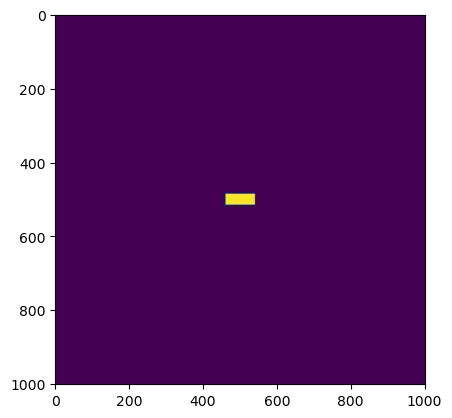

In [10]:
bmap = b*np.ones(nl)
lmap = np.ones(nb)*l

regionGR = bmap.copy()

conditionGR = ((bmap < 0.3) & (-1*bmap < 0.3) & (lmap < 0.8) & (-1*lmap < 0.8))  
regionGR[conditionGR] = 1
regionGR[~conditionGR] = 0
plt.imshow(regionGR)
#plt.colorbar()
#region
solidGR = p**2. * db*dl *np.sum(regionGR) 
print(solidGR)

In [11]:
J_GR = np.zeros(6)

J_GR[0] = p**2. *db*dl*np.sum(J_bar[:,:,0]*regionGR)/solidGR
J_GR[1] = p**2. *db*dl*np.sum(J_bar[:,:,4]*regionGR)/solidGR
J_GR[2] = p**2. *db*dl*np.sum(J_bar[:,:,8]*regionGR)/solidGR
J_GR[3] = p**2. *db*dl*np.sum(J_bar[:,:,1]*regionGR)/solidGR
J_GR[4] = p**2. *db*dl*np.sum(J_bar[:,:,5]*regionGR)/solidGR
J_GR[5] = p**2. *db*dl*np.sum(J_bar[:,:,9]*regionGR)/solidGR

In [12]:
print("ann Moore Einasto Isothermal decay Moore Einasto Isothermal")
print(' '.join(str(round(a,2)) for a in J_GR))



ann Moore Einasto Isothermal decay Moore Einasto Isothermal
7515.99 1635.74 17.24 28.34 22.36 6.4


## GC ring (1 degree)

0.0009556457693548622


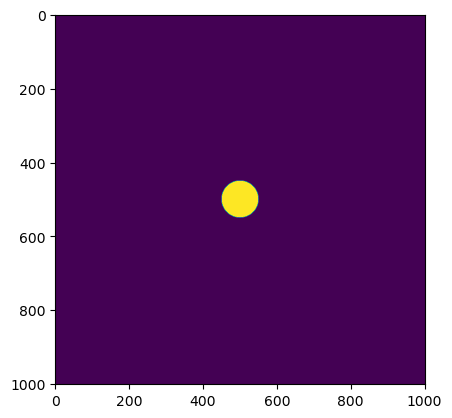

In [13]:
th =  np.arccos(np.cos(b_rad)*np.cos(l_rad))
regionGC = th.copy()


conditionGC = (th <= 1e0*p)

regionGC[conditionGC] = 1
regionGC[~conditionGC] = 0

plt.imshow(regionGC)
#plt.colorbar()
#region
solidGC = p**2. * db*dl *np.sum(regionGC) 
print(solidGC)

In [14]:
J_GC = np.zeros(6)

J_GC[0] = p**2. *db*dl*np.sum(J_bar[:,:,0]*regionGC)/solidGC
J_GC[1] = p**2. *db*dl*np.sum(J_bar[:,:,4]*regionGC)/solidGC
J_GC[2] = p**2. *db*dl*np.sum(J_bar[:,:,8]*regionGC)/solidGC
J_GC[3] = p**2. *db*dl*np.sum(J_bar[:,:,1]*regionGC)/solidGC
J_GC[4] = p**2. *db*dl*np.sum(J_bar[:,:,5]*regionGC)/solidGC
J_GC[5] = p**2. *db*dl*np.sum(J_bar[:,:,9]*regionGC)/solidGC

In [15]:
print("ann Moore Einasto Isothermal decay Moore Einasto Isothermal")
print(' '.join(str(round(a,2)) for a in J_GC))



ann Moore Einasto Isothermal decay Moore Einasto Isothermal
3732.88 1218.86 17.23 24.91 21.14 6.4


# J-factors for ON/OFF analysis in the GC region

In [2]:
########################
# NFW profile
import numpy as np
from matplotlib import pyplot as plt
from scipy import integrate as integrate
import pandas as pd


[rs_1, rho_1, 
 rs_2, rho_2, 
 rs_3, rho_3, 
 rs_4, rho_4, 
 rs_5, rho_5, 
 rs_6, rho_6] = [24.42, 0.184,
  28.44, 0.033,
  35.24, 0.021,
4.38, 1.387,
12.67, 0.712,
 30.28, 0.105] 
[alpha_1, alpha_2] = [0.17, 0.11]
[rs_CTA, rho_CTA] = [20,0.081]


r_Sun = 8.33
rho_Sun = 0.3

kpc_cm = 3.086e21




from scipy.interpolate import interp1d as interp1d

s_int = np.logspace(-4,2.3,100000)

#theta = np.logspace(-10,-3,1000) + np.linspace(1e-10, np.pi, 1000)
theta = np.logspace(-10,np.log10(np.pi+1e-10), 1000)

def rhoNFW_int(s,theta):
  rhoNFW_int = rhoNFW(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_1,rho_1)
  return rhoNFW_int

def rhoNFW_int2(s,theta):
  rhoNFW_int2 = rhoNFW_int(s,theta)**2
  return rhoNFW_int2

def J_NFW_ann(theta):
  J_NFW = integrate.simps(rhoNFW_int2(s_int,theta), s_int) 
  #J_NFW = integrate.quad(rhoNFW_int2,0, 200, args = (theta))[0] / (r_Sun*rho_Sun**2)
  return J_NFW
J_NFW_ann = np.vectorize(J_NFW_ann)
J_NFW_ann = interp1d(theta, J_NFW_ann(theta))

def J_NFW_dec(theta):
  J_NFW = integrate.simps(rhoNFW_int(s_int,theta), s_int) 
  #J_NFW = integrate.quad(rhoNFW_int,0, 200, args = (theta))[0] / (r_Sun*rho_Sun)
  return J_NFW
J_NFW_dec = np.vectorize(J_NFW_dec)
J_NFW_dec = interp1d(theta, J_NFW_dec(theta))




################################
# Usual Einasto profile





def rhoEin_int(s,theta):
  rhoEin_int = rhoEin(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_CTA,rho_CTA,alpha_1)
  return rhoEin_int 

def rhoEin_int2(s,theta):
  rhoEin_int2 = rhoEin_int(s,theta)**2
  return rhoEin_int2

def J_Ein_ann(theta):
  J_Ein = integrate.simps(rhoEin_int2(s_int,theta), s_int)
  return J_Ein
J_Ein_ann = np.vectorize(J_Ein_ann)
J_Ein_ann = interp1d(theta, J_Ein_ann(theta))

def J_Ein_dec(theta):
  J_Ein = integrate.simps(rhoEin_int(s_int,theta), s_int)
  return J_Ein
J_Ein_dec = np.vectorize(J_Ein_dec)  
J_Ein_dec = interp1d(theta, J_Ein_dec(theta))




################################
# Modified Einasto profile





def rhoEinB_int(s,theta):
  rhoEinB_int = rhoEin(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_2,rho_2,alpha_1)
  return rhoEinB_int 

def rhoEinB_int2(s,theta):
  rhoEinB_int2 = rhoEinB_int(s,theta)**2
  return rhoEinB_int2

def J_EinB_ann(theta):
  J_EinB = integrate.simps(rhoEinB_int2(s_int,theta), s_int)
  return J_EinB
J_EinB_ann = np.vectorize(J_EinB_ann)
J_EinB_ann = interp1d(theta, J_EinB_ann(theta))

def J_EinB_dec(theta):
  J_EinB = integrate.simps(rhoEinB_int(s_int,theta), s_int)
  return J_EinB
J_EinB_dec = np.vectorize(J_EinB_dec)
J_EinB_dec = interp1d(theta, J_EinB_dec(theta))




################################
# Isotermal profile





def rhoIso_int(s,theta):
  rhoIso_int = rhoIso(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_4,rho_4)
  return rhoIso_int

def rhoIso_int2(s,theta):
  rhoIso_int2 = rhoIso_int(s,theta)**2
  return rhoIso_int2

def J_Iso_ann(theta):
  J_Iso = integrate.simps(rhoIso_int2(s_int,theta), s_int)
  return J_Iso
J_Iso_ann = np.vectorize(J_Iso_ann)
J_Iso_ann = interp1d(theta, J_Iso_ann(theta))

def J_Iso_dec(theta):
  J_Iso = integrate.simps(rhoIso_int(s_int,theta), s_int)
  return J_Iso
J_Iso_dec = np.vectorize(J_Iso_dec)  
J_Iso_dec = interp1d(theta, J_Iso_dec(theta))


################################
# Burket profile





def rhoBur_int(s,theta):
  rhoBur_int = rhoBur(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_5,rho_5)
  return rhoBur_int

def rhoBur_int2(s,theta):
  rhoBur_int2 = rhoBur_int(s,theta)**2
  return rhoBur_int2

def J_Bur_ann(theta):
  J_Bur = integrate.simps(rhoBur_int2(s_int,theta), s_int)
  return J_Bur
J_Bur_ann = np.vectorize(J_Bur_ann)
J_Bur_ann = interp1d(theta, J_Bur_ann(theta))

def J_Bur_dec(theta):
  J_Bur = integrate.simps(rhoBur_int(s_int,theta), s_int) 
  return J_Bur
J_Bur_dec = np.vectorize(J_Bur_dec)  
J_Bur_dec = interp1d(theta, J_Bur_dec(theta))




################################
# Moore profile





def rhoMoo_int(s,theta):
  rhoMoo_int = rhoMoo(np.sqrt(r_Sun**2 + s**2 -2.*r_Sun*s*np.cos(theta)),rs_6,rho_6)
  return rhoMoo_int

def rhoMoo_int2(s,theta):
  rhoMoo_int2 = rhoMoo_int(s,theta)**2
  return rhoMoo_int2

def J_Moo_ann(theta):
  J_Moo = integrate.simps(rhoMoo_int2(s_int,theta), s_int)
  return J_Moo
J_Moo_ann = np.vectorize(J_Moo_ann)
J_Moo_ann = interp1d(theta, J_Moo_ann(theta))

def J_Moo_dec(theta):
  J_Moo = integrate.simps(rhoMoo_int(s_int,theta), s_int)
  return J_Moo
J_Moo_dec = np.vectorize(J_Moo_dec)  
J_Moo_dec = interp1d(theta, J_Moo_dec(theta))

In [3]:
factor = (0.4/0.3)

/tmp/ipykernel_15276/188709137.py:51: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-b" (-> linestyle='-'). The keyword argument will take precedence.
  ax12.plot(t2, factor**2.*J_NFW_ann(t2)*kpc_cm, '-b', linestyle='solid',linewidth=2)


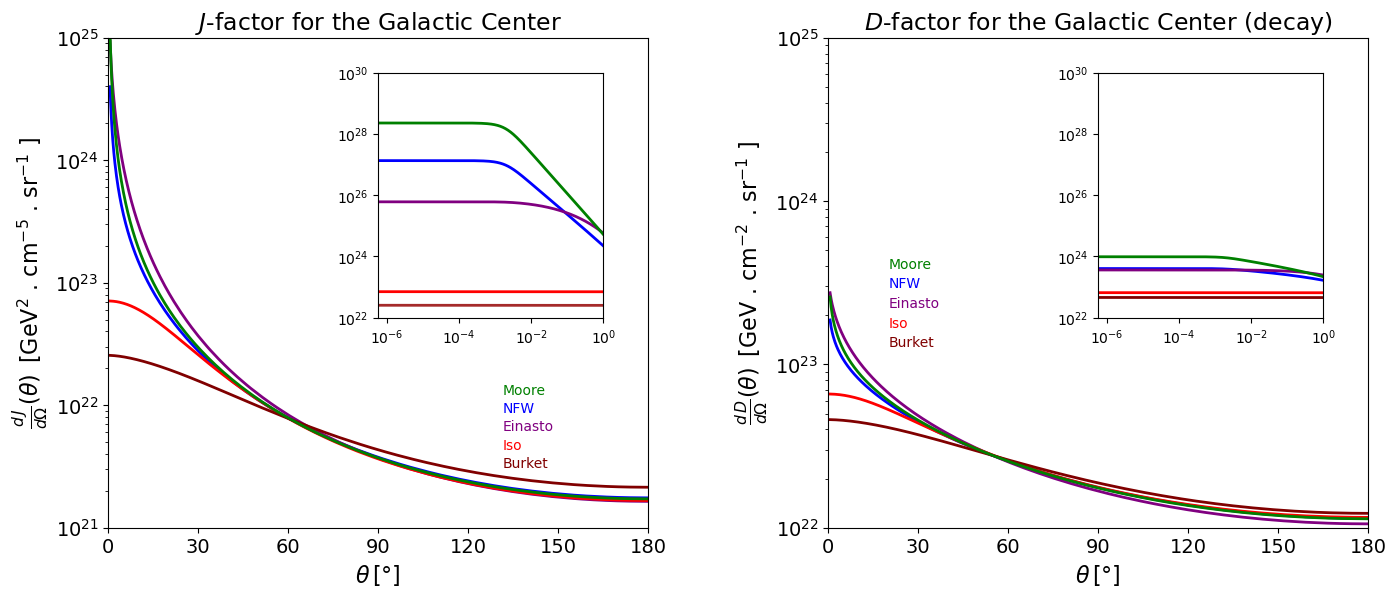

In [6]:
fig = plt.figure(figsize= (18,7))
ax1 = fig.add_axes([0.1, 0.1, 0.3, 0.7])
ax2 = fig.add_axes([0.5, 0.1, 0.3, 0.7])
ax12 = fig.add_axes([0.25, 0.4, 0.125, 0.35])
#[0.25, 0.5, 0.125, 0.25]
ax22 = fig.add_axes([0.65, 0.4, 0.125, 0.35])

# (20, 8)
t = np.linspace(1e-2, np.pi, 1000)
#t = np.linspace(1e-2, np.pi/18., 1000)
#t = np.logspace(-2, np.log10(np.pi), 1000)
#print(t[-1])

ax1.set_yscale('log')
ax1.set_xlim(0,np.pi)
#ax1.set_xlim(0,np.pi/18.)
ax1.set_ylim(1e21,1e25)
ax1.plot(t, factor**2.*J_NFW_ann(t)*kpc_cm, '-b',linewidth=2)
#ax1.plot(t, J_EinB_ann(t)*kpc_cm, color = 'hotpink', linestyle='solid')
ax1.plot(t, J_Ein_ann(t)*kpc_cm, color = 'purple',linewidth=2)
ax1.plot(t, factor**2.*J_Iso_ann(t)*kpc_cm, color = 'r',linewidth=2)
ax1.plot(t, factor**2.*J_Bur_ann(t)*kpc_cm, color = 'maroon',linewidth=2)
ax1.plot(t, factor**2.*J_Moo_ann(t)*kpc_cm, color = 'green',linewidth=2)
ax1.set_xticks(0.0175*np.array([0,30,60,90,120,150,180]))
#ax1.set_xticks(np.pi*np.arange(0.,1.16,1/6))
ax1.set_xticklabels(['0','30','60','90','120','150','180'],fontsize=14)
ax1.set_xlabel(r'$\theta \,[°]$',fontsize=16)
ax1.set_yticks([1e21,1e22,1e23,1e24,1e25])
ax1.set_yticklabels([r'$10^{21}$',r'$10^{22}$',r'$10^{23}$',r'$10^{24}$',r'$10^{25}$'],fontsize=14)
ax1.set_ylabel(r'$ \frac{d\, J}{d \Omega} (\theta) \, $ [GeV$^2$ . cm$^{-5}$ . sr$^{-1}$ ]',fontsize=16)
#ax11 = ax1.twinx()
#ax11.set_yscale('log')
#ax11.set_ylim(.3,1e3)
#ax11.set_ylabel('')
#ax11.set_yticklabels('')

ax1.text(2.3,4*kpc_cm,r'Moore', color = 'green')
ax1.text(2.3,4*10**(-0.15)*kpc_cm,r'NFW', color = 'blue')
ax1.text(2.3,4*10**(-0.3)*kpc_cm,r'Einasto', color = 'purple')
ax1.text(2.3,4*10**(-0.45)*kpc_cm,r'Iso', color = 'red')
ax1.text(2.3,4*10**(-0.60)*kpc_cm,r'Burket', color = 'maroon')
#ax1.text(2.3,4*10**(-0.75)*kpc_cm,r'Burket', color = 'maroon')


t2 = np.logspace(-9,0,500) 

ax12.set_xscale('log')
ax12.set_yscale('log')
ax12.set_xlim(1e-8,1e-2)
ax12.set_ylim(1e22,1e30)
ax12.plot(t2, factor**2.*J_NFW_ann(t2)*kpc_cm, '-b', linestyle='solid',linewidth=2)
ax12.plot(t2, J_Ein_ann(t2)*kpc_cm, color = 'purple', linestyle='solid',linewidth=2)
#ax12.plot(t2, factor**2.*J_EinB_ann(t2)*kpc_cm, color = 'hotpink', linestyle='solid')
ax12.plot(t2, factor**2.*J_Iso_ann(t2)*kpc_cm, color = 'r', linestyle='solid',linewidth=2)
ax12.plot(t2, factor**2.*J_Bur_ann(t2)*kpc_cm, color = 'brown', linestyle='solid',linewidth=2)
ax12.plot(t2, factor**2.*J_Moo_ann(t2)*kpc_cm, color = 'green', linestyle='solid',linewidth=2)
ax12.set_xticks([0.0175*1e-6,0.0175*1e-4,0.0175*1e-2,0.0175*1e0])
#ax12.set_yticks([1.*kpc_cm,1e2*kpc_cm,1e4*kpc_cm,1e6*kpc_cm,1e8*kpc_cm,1e10*kpc_cm])
ax12.set_xticklabels([r'$10^{-6}$',r'$10^{-4}$',r'$10^{-2}$',r'$10^0$'])


####################################
# right plot

ax2.set_yscale('log')
ax2.set_xlim(0,np.pi)
#ax2.set_xlim(0,np.pi/18.)
ax2.set_ylim(1e22,1e25)
ax2.plot(t, factor*J_NFW_dec(t)*kpc_cm, '-b',linewidth=2)
#ax2.plot(t, J_EinB_dec(t)*kpc_cm, color = 'hotpink', linestyle='solid')
ax2.plot(t, J_Ein_dec(t)*kpc_cm, color = 'purple', linestyle='solid',linewidth=2)
ax2.plot(t, factor*J_Iso_dec(t)*kpc_cm, color = 'r', linestyle='solid',linewidth=2)
ax2.plot(t, factor*J_Bur_dec(t)*kpc_cm, color = 'maroon', linestyle='solid',linewidth=2)
ax2.plot(t, factor*J_Moo_dec(t)*kpc_cm, color = 'green', linestyle='solid',linewidth=2)
ax2.set_xticks(0.0175*np.array([0,30,60,90,120,150,180]))
ax2.set_xticklabels(['0','30','60','90','120','150','180'],fontsize=14)
ax2.set_xlabel(r'$\theta \,[°]$',fontsize=16)
ax2.set_yticks([1e22,1e23,1e24,1e25])
ax2.set_yticklabels([r'$10^{22}$',r'$10^{23}$',r'$10^{24}$',r'$10^{25}$'],fontsize=14)
#ax2.set_yticks([1*kpc_cm,1e1*kpc_cm,1e2*kpc_cm,1e3*kpc_cm,1e4*kpc_cm])
#ax2.set_yticklabels([r'$1$',r'$10$',r'$10^2$',r'$10^3$',r'$10^4$'],fontsize=12)
#ax2.set_ylabel(r'$ \frac{d J}{d \Omega} (\theta) \, [\rho_\odot \, r_\odot]$ ',fontsize=13)
ax2.set_ylabel(r'$ \frac{d\, D}{d \Omega} (\theta) \, $ [GeV . cm$^{-2}$ . sr$^{-1}$ ]',fontsize=16)

ax2.text(0.35,10**(2.10)*kpc_cm,r'Moore', color = 'green')
#ax2.text(0.35,4*10**(-0.15)*kpc_cm,r'Moore', color = 'green')
ax2.text(0.35,10**(1.98)*kpc_cm,r'NFW', color = 'blue')
ax2.text(0.35,10**(1.86)*kpc_cm,r'Einasto', color = 'purple')
ax2.text(0.35,10**(1.74)*kpc_cm,r'Iso', color = 'red')
ax2.text(0.35,10**(1.62)*kpc_cm,r'Burket', color = 'maroon')
#ax2.text(0.35,10**(1.50)*kpc_cm,r'Burket', color = 'maroon')




ax22.set_xscale('log')
ax22.set_yscale('log')
#ax22.set_xlim(1e-9,2,500)
ax22.set_xlim(1e-8,1e-2)
ax22.set_ylim(1e22,1e30)
ax22.plot(t2, factor*J_NFW_dec(t2)*kpc_cm, '-b',linewidth=2)
ax22.plot(t2, J_Ein_dec(t2)*kpc_cm, color = 'purple', linestyle='solid',linewidth=2)
#ax22.plot(t2, factor*J_EinB_dec(t2)*kpc_cm, color = 'hotpink')
ax22.plot(t2, factor*J_Iso_dec(t2)*kpc_cm, color = 'r',linewidth=2)
ax22.plot(t2, factor*J_Bur_dec(t2)*kpc_cm, color = 'maroon',linewidth=2)
ax22.plot(t2, factor*J_Moo_dec(t2)*kpc_cm, color = 'green',linewidth=2)
#ax22.set_xticks([1e-8,1e-6,1e-4,1e-2,1.])
##ax22.set_yticks([1.*kpc_cm,1e2*kpc_cm,1e4*kpc_cm,1e6*kpc_cm,1e8*kpc_cm,1e10*kpc_cm])
ax22.set_xticks([0.0175*1e-6,0.0175*1e-4,0.0175*1e-2,0.0175*1e0])
#ax12.set_yticks([1.*kpc_cm,1e2*kpc_cm,1e4*kpc_cm,1e6*kpc_cm,1e8*kpc_cm,1e10*kpc_cm])
ax22.set_xticklabels([r'$10^{-6}$',r'$10^{-4}$',r'$10^{-2}$',r'$10^0$'])

#ax1.set_title(r"$J$-factor for the Galactic Center (annihilation)",fontsize=17)
ax1.set_title(r"$J$-factor for the Galactic Center",fontsize=17)
ax2.set_title(r"$D$-factor for the Galactic Center (decay)",fontsize=17)

#ax1.scatter(t[0],J_EinB_ann(t[0]))

plt.savefig("Jfactor_curve_final2.pdf",bbox_inches='tight')

In [123]:
rho_Sun * r_Sun*kpc_cm

7.711914e+21

In [27]:
kpc_cm

3.086e+21

In [33]:
factor

1.3333333333333335

In [7]:
[bmin, bmax] = [-1e1, 1e1]
[lmin, lmax] = [-1e1, 1e1]
[db, dl] = [2e-2, 2e-2]
b = np.arange(bmin, bmax + db, db)
l = np.arange(lmin, lmax + dl, dl)
nb = len(b)
nl = len(l)
b = b.reshape([nb, 1])
p = np.pi/180. # converts degrees to radians
[b_rad, l_rad] = [p*b, p*l]

th =  np.arccos(np.cos(b_rad)*np.cos(l_rad))
J = np.zeros([nb, nl, 12])
J_bar = np.zeros([nb, nl, 12])

#eliminar ângulos menores que < 1e-2 degrees
condition = th < (1e-2*p)
th[condition] = 1e-2*p
J[:,:,2] = J_NFW_ann(th)*kpc_cm*factor**2.
J[:,:,3] = J_NFW_dec(th)*kpc_cm*factor
J[:,:,4] = J_Ein_ann(th)*kpc_cm*factor**2.
J[:,:,5] = J_Ein_dec(th)*kpc_cm*factor
J[:,:,6] = J_EinB_ann(th)*kpc_cm*factor**2.
J[:,:,7] = J_EinB_dec(th)*kpc_cm*factor
J[:,:,8] = J_Iso_ann(th)*kpc_cm*factor**2.
J[:,:,9] = J_Iso_dec(th)*kpc_cm*factor
J[:,:,10] = J_Bur_ann(th)*kpc_cm*factor**2.
J[:,:,11] = J_Bur_dec(th)*kpc_cm*factor
J[:,:,0] = J_Moo_ann(th)*kpc_cm*factor**2.
J[:,:,1] = J_Moo_dec(th)*kpc_cm*factor

J_bar[:,:,0] = J[:,:,0]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,1] = J[:,:,1]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,2] = J[:,:,2]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,3] = J[:,:,3]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,4] = J[:,:,4]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,5] = J[:,:,5]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,6] = J[:,:,6]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,7] = J[:,:,7]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,8] = J[:,:,8]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,9] = J[:,:,9]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,10] = J[:,:,10]*np.cos(b_rad)*np.ones(nl)
J_bar[:,:,11] = J[:,:,11]*np.cos(b_rad)*np.ones(nl)

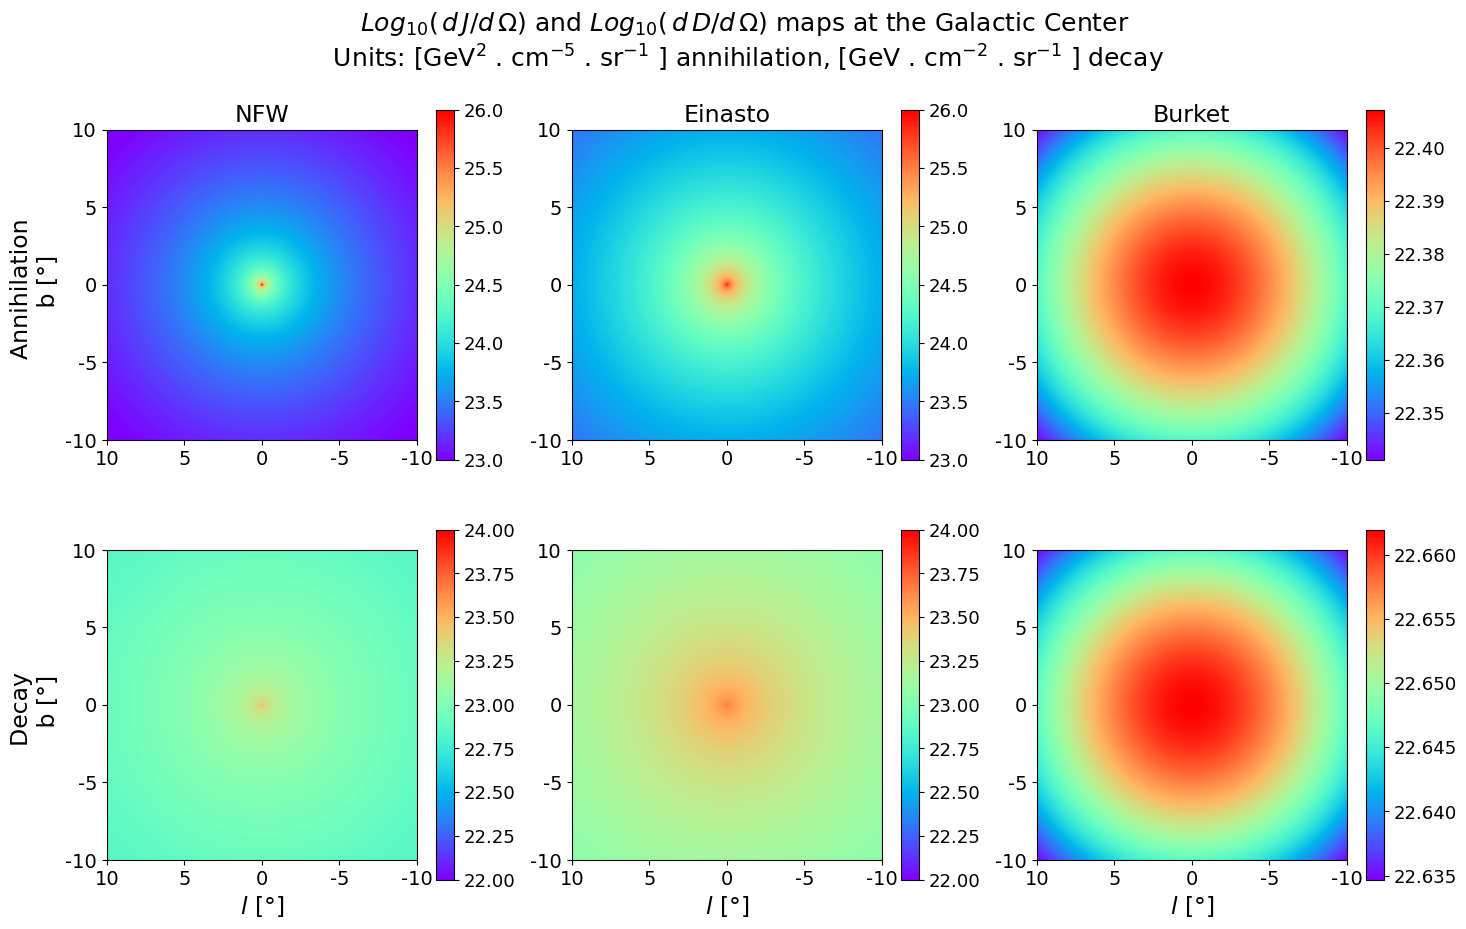

In [8]:
fig, axs = plt.subplots(2,3, figsize = (17,10)) 
cmap = 'rainbow'
#im1 = axs[0,0].imshow(np.log10(J[:,:,0]), cmap = cmap, vmin = 22, vmax = 26,origin='lower',extent=(lmax,lmin,bmin,bmax))
#im2 = axs[1,0].imshow(np.log10(J[:,:,1]), cmap = cmap, vmin = 22, vmax = 24,origin='lower',extent=(lmax,lmin,bmin,bmax))
im1 = axs[0,0].imshow(np.log10(J[:,:,2]), cmap = cmap, vmin = 23, vmax = 26,origin='lower',extent=(lmax,lmin,bmin,bmax))
im2 = axs[1,0].imshow(np.log10(J[:,:,3]), cmap = cmap, vmin = 22, vmax = 24,origin='lower',extent=(lmax,lmin,bmin,bmax))
im3 = axs[0,1].imshow(np.log10(J[:,:,4]), cmap = cmap, vmin = 23, vmax = 26,origin='lower',extent=(lmax,lmin,bmin,bmax))
im4 = axs[1,1].imshow(np.log10(J[:,:,5]), cmap = cmap, vmin = 22, vmax = 24,origin='lower',extent=(lmax,lmin,bmin,bmax))
#im7 = axs[0,3].imshow(np.log10(J[:,:,6]), cmap = cmap, vmin = 22, vmax = 26,origin='lower',extent=(lmax,lmin,bmin,bmax))
#im8 = axs[1,3].imshow(np.log10(J[:,:,7]), cmap = cmap, vmin = 22, vmax = 24, origin='lower',extent=(lmax,lmin,bmin,bmax))
#im9 = axs[0,4].imshow(np.log10(J[:,:,8]), cmap = cmap, vmin = np.log10(np.min(J[:,:,8])), vmax = np.log10(np.max(J[:,:,8])),origin='lower',extent=(lmax,lmin,bmin,bmax))
#im10 = axs[1,4].imshow(np.log10(J[:,:,9]), cmap = cmap, vmin = np.log10(np.min(J[:,:,9])), vmax = np.log10(np.max(J[:,:,9])),origin='lower',extent=(lmax,lmin,bmin,bmax))
im5 = axs[0,2].imshow(np.log10(J[:,:,10]), cmap = cmap, vmin = np.log10(np.min(J[:,:,10])), vmax = np.log10(np.max(J[:,:,10])),origin='lower',extent=(lmax,lmin,bmin,bmax))
im6 = axs[1,2].imshow(np.log10(J[:,:,11]), cmap = cmap, vmin = np.log10(np.min(J[:,:,11])), vmax = np.log10(np.max(J[:,:,11])),origin='lower',extent=(lmax,lmin,bmin,bmax))

fig.suptitle(r"$Log_{10}\left(\,d \, J / d\, \Omega \right)$ and $Log_{10}\left(\,d \,D/ d\, \Omega \right)$ maps at the Galactic Center"+"\n"+r" Units: [GeV$^2$ . cm$^{-5}$ . sr$^{-1}$ ] annihilation, [GeV . cm$^{-2}$ . sr$^{-1}$ ] decay",fontsize=18)
#fig.subtitle(r" Units: [GeV$^2$ . cm$^{-5}$ . sr$^{-1}$ ] annihilation, [GeV . cm$^{-2}$ . sr$^{-1}$ ] decay",fontsize=15)
#axs[0,0].set_title("Annihilation")
#axs[0,1].set_title("Decay")
#axs[0,0].set_ylabel("NFW \n b [°]")
#axs[1,0].set_ylabel("Einasto \n b [°]")
#axs[2,0].set_ylabel("Einanto B \n b [°]")
#axs[3,0].set_ylabel("Isothermal \n b [°]")
#axs[4,0].set_ylabel("Burket \n b [°]")
#axs[5,0].set_ylabel("Moore \n b [°]")
#axs[5,0].set_xlabel(r"$l$ [°]")
#axs[5,1].set_xlabel(r"$l$ [°]")

#axs[0,0].set_title("")
#axs[0,1].set_title("")
axs[0,0].set_title("NFW",fontsize=17)
axs[0,1].set_title("Einasto",fontsize=17)
#axs[0,3].set_title("Einanto B",fontsize=20)
#axs[0,4].set_title("Isothermal",fontsize=20)
axs[0,2].set_title("Burket",fontsize=17)
#axs[0,0].set_title("Moore",fontsize=20)

axs[0,0].set_ylabel("Annihilation \n b [°]",fontsize=17)
axs[1,0].set_ylabel("Decay \n b [°]",fontsize=17)

axs[1,0].set_xlabel(r"$l$ [°]",fontsize=17)
axs[1,1].set_xlabel(r"$l$ [°]",fontsize=17)
axs[1,2].set_xlabel(r"$l$ [°]",fontsize=17)
#axs[1,3].set_xlabel(r"$l$ [°]",fontsize=20)
#axs[1,4].set_xlabel(r"$l$ [°]",fontsize=20)
#axs[1,5].set_xlabel(r"$l$ [°]",fontsize=20)


axs[0,0].set_xticks([-10,-5,0,5,10])
axs[0,1].set_xticks([-10,-5,0,5,10])
axs[0,2].set_xticks([-10,-5,0,5,10])
#axs[0,3].set_xticks([-10,-5,0,5,10])
#axs[0,4].set_xticks([-10,-5,0,5,10])
#axs[0,5].set_xticks([-10,-5,0,5,10])
axs[1,0].set_xticks([-10,-5,0,5,10])
axs[1,1].set_xticks([-10,-5,0,5,10])
axs[1,2].set_xticks([-10,-5,0,5,10])
#axs[1,3].set_xticks([-10,-5,0,5,10])
#axs[1,4].set_xticks([-10,-5,0,5,10])
#axs[1,5].set_xticks([-10,-5,0,5,10])

axs[0,0].set_yticks([-10,-5,0,5,10])
axs[0,1].set_yticks([-10,-5,0,5,10])
axs[0,2].set_yticks([-10,-5,0,5,10])
#axs[0,3].set_yticks([-10,-5,0,5,10])
#axs[0,4].set_yticks([-10,-5,0,5,10])
#axs[0,5].set_yticks([-10,-5,0,5,10])
axs[1,0].set_yticks([-10,-5,0,5,10])
axs[1,1].set_yticks([-10,-5,0,5,10])
axs[1,2].set_yticks([-10,-5,0,5,10])
#axs[1,3].set_yticks([-10,-5,0,5,10])
#axs[1,4].set_yticks([-10,-5,0,5,10])
#axs[1,5].set_yticks([-10,-5,0,5,10])


axs[0,0].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,1].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,2].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,3].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,4].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,5].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,0].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,1].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,2].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,3].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,4].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,5].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)

axs[0,0].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,1].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[0,2].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,3].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,4].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,5].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,0].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,1].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1,2].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,3].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,4].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,5].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)


cbar1 = fig.colorbar(im1, ax = axs[0,0])
cbar2 = fig.colorbar(im2, ax = axs[1,0])
cbar3 = fig.colorbar(im3, ax = axs[0,1])
cbar4 = fig.colorbar(im4, ax = axs[1,1])
cbar5 = fig.colorbar(im5, ax = axs[0,2])
cbar6 = fig.colorbar(im6, ax = axs[1,2])
#cbar7 = fig.colorbar(im7, ax = axs[0,3])
#cbar8 = fig.colorbar(im8, ax = axs[1,3])
#cbar9 = fig.colorbar(im9, ax = axs[0,4])
#cbar10 = fig.colorbar(im10, ax = axs[1,4])
#cbar11 = fig.colorbar(im11, ax = axs[0,5])
#cbar12 = fig.colorbar(im12, ax = axs[1,5])


cbar1.ax.tick_params(labelsize=13)
cbar2.ax.tick_params(labelsize=13)
cbar3.ax.tick_params(labelsize=13)
cbar4.ax.tick_params(labelsize=13)
cbar5.ax.tick_params(labelsize=13)
cbar6.ax.tick_params(labelsize=13)
#cbar7.ax.tick_params(labelsize=13)
#cbar8.ax.tick_params(labelsize=13)
#cbar9.ax.tick_params(labelsize=13)
#cbar10.ax.tick_params(labelsize=13)
#cbar11.ax.tick_params(labelsize=13)
#cbar12.ax.tick_params(labelsize=13)

#plt.savefig("J_map_final.pdf")
#plt.imshow(np.log10(J_bar[:,:,0]), cmap = 'rainbow', vmin = 0.5, vmax = 4)
#plt.colorbar() 

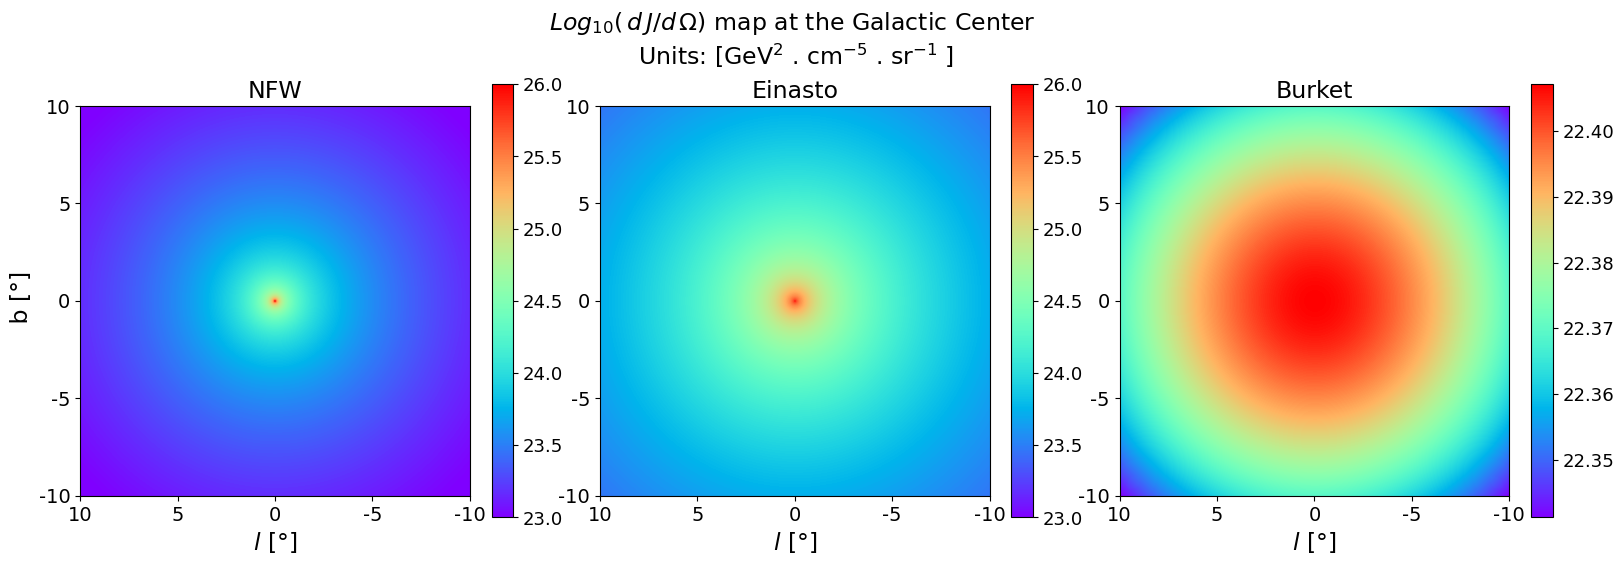

In [44]:
fig, axs = plt.subplots(1,3, figsize = (19,6)) 
cmap = 'rainbow'
#im1 = axs[0,0].imshow(np.log10(J[:,:,0]), cmap = cmap, vmin = 22, vmax = 26,origin='lower',extent=(lmax,lmin,bmin,bmax))
#im2 = axs[1,0].imshow(np.log10(J[:,:,1]), cmap = cmap, vmin = 22, vmax = 24,origin='lower',extent=(lmax,lmin,bmin,bmax))
im1 = axs[0].imshow(np.log10(J[:,:,2]), cmap = cmap, vmin = 23, vmax = 26,origin='lower',extent=(lmax,lmin,bmin,bmax))
#im2 = axs[1,0].imshow(np.log10(J[:,:,3]), cmap = cmap, vmin = 22, vmax = 24,origin='lower',extent=(lmax,lmin,bmin,bmax))
im3 = axs[1].imshow(np.log10(J[:,:,4]), cmap = cmap, vmin = 23, vmax = 26,origin='lower',extent=(lmax,lmin,bmin,bmax))
#im4 = axs[1,1].imshow(np.log10(J[:,:,5]), cmap = cmap, vmin = 22, vmax = 24,origin='lower',extent=(lmax,lmin,bmin,bmax))
#im7 = axs[0,3].imshow(np.log10(J[:,:,6]), cmap = cmap, vmin = 22, vmax = 26,origin='lower',extent=(lmax,lmin,bmin,bmax))
#im8 = axs[1,3].imshow(np.log10(J[:,:,7]), cmap = cmap, vmin = 22, vmax = 24, origin='lower',extent=(lmax,lmin,bmin,bmax))
#im9 = axs[0,4].imshow(np.log10(J[:,:,8]), cmap = cmap, vmin = np.log10(np.min(J[:,:,8])), vmax = np.log10(np.max(J[:,:,8])),origin='lower',extent=(lmax,lmin,bmin,bmax))
#im10 = axs[1,4].imshow(np.log10(J[:,:,9]), cmap = cmap, vmin = np.log10(np.min(J[:,:,9])), vmax = np.log10(np.max(J[:,:,9])),origin='lower',extent=(lmax,lmin,bmin,bmax))
im5 = axs[2].imshow(np.log10(J[:,:,10]), cmap = cmap, vmin = np.log10(np.min(J[:,:,10])), vmax = np.log10(np.max(J[:,:,10])),origin='lower',extent=(lmax,lmin,bmin,bmax))
#im6 = axs[1,2].imshow(np.log10(J[:,:,11]), cmap = cmap, vmin = np.log10(np.min(J[:,:,11])), vmax = np.log10(np.max(J[:,:,11])),origin='lower',extent=(lmax,lmin,bmin,bmax))

fig.suptitle(r"$Log_{10}\left(\,d \, J / d\, \Omega \right)$ map at the Galactic Center"+"\n"+r" Units: [GeV$^2$ . cm$^{-5}$ . sr$^{-1}$ ]",fontsize=17)
#fig.subtitle(r" Units: [GeV$^2$ . cm$^{-5}$ . sr$^{-1}$ ] annihilation, [GeV . cm$^{-2}$ . sr$^{-1}$ ] decay",fontsize=15)
#axs[0,0].set_title("Annihilation")
#axs[0,1].set_title("Decay")
#axs[0,0].set_ylabel("NFW \n b [°]")
#axs[1,0].set_ylabel("Einasto \n b [°]")
#axs[2,0].set_ylabel("Einanto B \n b [°]")
#axs[3,0].set_ylabel("Isothermal \n b [°]")
#axs[4,0].set_ylabel("Burket \n b [°]")
#axs[5,0].set_ylabel("Moore \n b [°]")
#axs[5,0].set_xlabel(r"$l$ [°]")
#axs[5,1].set_xlabel(r"$l$ [°]")

#axs[0,0].set_title("")
#axs[0,1].set_title("")
axs[0].set_title("NFW",fontsize=17)
axs[1].set_title("Einasto",fontsize=17)
#axs[0,3].set_title("Einanto B",fontsize=20)
#axs[0,4].set_title("Isothermal",fontsize=20)
axs[2].set_title("Burket",fontsize=17)
#axs[0,0].set_title("Moore",fontsize=20)

axs[0].set_ylabel(" b [°]",fontsize=17)
#axs[1,0].set_ylabel("Decay \n b [°]",fontsize=17)

axs[0].set_xlabel(r"$l$ [°]",fontsize=17)
axs[1].set_xlabel(r"$l$ [°]",fontsize=17)
axs[2].set_xlabel(r"$l$ [°]",fontsize=17)
#axs[1,3].set_xlabel(r"$l$ [°]",fontsize=20)
#axs[1,4].set_xlabel(r"$l$ [°]",fontsize=20)
#axs[1,5].set_xlabel(r"$l$ [°]",fontsize=20)


axs[0].set_xticks([-10,-5,0,5,10])
axs[1].set_xticks([-10,-5,0,5,10])
axs[2].set_xticks([-10,-5,0,5,10])
#axs[0,3].set_xticks([-10,-5,0,5,10])
#axs[0,4].set_xticks([-10,-5,0,5,10])
#axs[0,5].set_xticks([-10,-5,0,5,10])
#axs[1,0].set_xticks([-10,-5,0,5,10])
#axs[1,1].set_xticks([-10,-5,0,5,10])
#axs[1,2].set_xticks([-10,-5,0,5,10])
#axs[1,3].set_xticks([-10,-5,0,5,10])
#axs[1,4].set_xticks([-10,-5,0,5,10])
#axs[1,5].set_xticks([-10,-5,0,5,10])

axs[0].set_yticks([-10,-5,0,5,10])
axs[1].set_yticks([-10,-5,0,5,10])
axs[2].set_yticks([-10,-5,0,5,10])
#axs[0,3].set_yticks([-10,-5,0,5,10])
#axs[0,4].set_yticks([-10,-5,0,5,10])
#axs[0,5].set_yticks([-10,-5,0,5,10])
#axs[1,0].set_yticks([-10,-5,0,5,10])
#axs[1,1].set_yticks([-10,-5,0,5,10])
#axs[1,2].set_yticks([-10,-5,0,5,10])
#axs[1,3].set_yticks([-10,-5,0,5,10])
#axs[1,4].set_yticks([-10,-5,0,5,10])
#axs[1,5].set_yticks([-10,-5,0,5,10])


axs[0].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[2].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,3].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,4].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,5].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,0].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,1].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,2].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,3].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,4].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,5].set_xticklabels(['-10','-5','0','5','10'],fontsize=14)

axs[0].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[1].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
axs[2].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,3].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,4].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[0,5].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,0].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,1].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,2].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,3].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,4].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)
#axs[1,5].set_yticklabels(['-10','-5','0','5','10'],fontsize=14)


cbar1 = fig.colorbar(im1, ax = axs[0],fraction=0.05)
#cbar2 = fig.colorbar(im2, ax = axs[1,0])
cbar3 = fig.colorbar(im3, ax = axs[1],fraction=0.05)
#cbar4 = fig.colorbar(im4, ax = axs[1,1])
cbar5 = fig.colorbar(im5, ax = axs[2],fraction=0.05)
#cbar6 = fig.colorbar(im6, ax = axs[1,2])
#cbar7 = fig.colorbar(im7, ax = axs[0,3])
#cbar8 = fig.colorbar(im8, ax = axs[1,3])
#cbar9 = fig.colorbar(im9, ax = axs[0,4])
#cbar10 = fig.colorbar(im10, ax = axs[1,4])
#cbar11 = fig.colorbar(im11, ax = axs[0,5])
#cbar12 = fig.colorbar(im12, ax = axs[1,5])


cbar1.ax.tick_params(labelsize=13)
#cbar2.ax.tick_params(labelsize=13)
cbar3.ax.tick_params(labelsize=13)
#cbar4.ax.tick_params(labelsize=13)
cbar5.ax.tick_params(labelsize=13)
#cbar6.ax.tick_params(labelsize=13)
#cbar7.ax.tick_params(labelsize=13)
#cbar8.ax.tick_params(labelsize=13)
#cbar9.ax.tick_params(labelsize=13)
#cbar10.ax.tick_params(labelsize=13)
#cbar11.ax.tick_params(labelsize=13)
#cbar12.ax.tick_params(labelsize=13)

plt.savefig("J_map_final2.pdf")
#plt.imshow(np.log10(J_bar[:,:,0]), cmap = 'rainbow', vmin = 0.5, vmax = 4)
#plt.colorbar() 

In [9]:
[bmin, bmax] = [-1e1, 1e1]
[lmin, lmax] = [-1e1, 1e1]
[db, dl] = [2e-2, 2e-2]
b = np.arange(bmin, bmax + db, db)
l = np.arange(lmin, lmax + dl, dl)
nb = len(b)
nl = len(l)
b = b.reshape([nb, 1])
p = np.pi/180. # converts degrees to radians
[b_rad, l_rad] = [p*b, p*l]

th =  np.arccos(np.cos(b_rad)*np.cos(l_rad))
J = np.zeros([nb, nl])
J_bar = np.zeros([nb, nl])

#eliminar ângulos menores que < 1e-2 degrees
condition = th < (1e-2*p)
th[condition] = 1e-2*p

J[:,:] = J_Ein_ann(th)*kpc_cm
J_bar[:,:] = J[:,:]*np.cos(b_rad)*np.ones(nl)


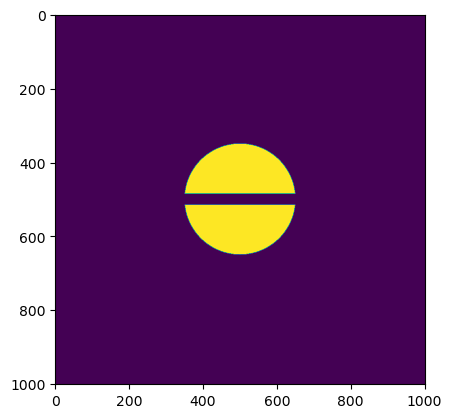

In [10]:
th =  np.arccos(np.cos(b_rad)*np.cos(l_rad))
bmap = b*np.ones(nl)
lmap = np.ones(nb)*l

regionGC = th.copy()
regionGR = bmap.copy()


conditionGC = (th <= 3e0*p)
regionGC[conditionGC] = 1
regionGC[~conditionGC] = 0

conditionGR = ((bmap < 0.3) & (-1*bmap < 0.3) & (lmap < 3.) & (-1*lmap < 3.))  
regionGR[conditionGR] = 0
regionGR[~conditionGR] = 1


regionGC = regionGC*regionGR
plt.imshow(regionGC)
#solidGC = p**2. * db*dl *np.sum(regionGC) 


In [15]:
# splitting the GC ring:
th_range = np.arange(0.5,3.1,0.1)

#cond_disks = []
disks = []


for i in range(len(th_range)-1):
    condition = (th > p*th_range[i]) & (th <= p*th_range[i+1])
    region = regionGC.copy()
    #cond_disks.append(condition)
    region[~condition] = 0
    disks.append(region)
    #disk[]
    #disks.append(regionGC*)
    
#cond_disks = np.array(cond_disks)
disks = np.array(disks)

In [16]:
solid = np.zeros(len(th_range)-1)
J_disks = np.zeros(len(th_range)-1)

solid[0] = p**2. * db*dl *np.sum(disks[0]*np.cos(b_rad)*np.ones(nl)) 
solid[1] = p**2. * db*dl *np.sum(disks[1]*np.cos(b_rad)*np.ones(nl)) 
solid[2] = p**2. * db*dl *np.sum(disks[2]*np.cos(b_rad)*np.ones(nl)) 
solid[3] = p**2. * db*dl *np.sum(disks[3]*np.cos(b_rad)*np.ones(nl)) 
solid[4] = p**2. * db*dl *np.sum(disks[4]*np.cos(b_rad)*np.ones(nl)) 
solid[5] = p**2. * db*dl *np.sum(disks[5]*np.cos(b_rad)*np.ones(nl)) 
solid[6] = p**2. * db*dl *np.sum(disks[6]*np.cos(b_rad)*np.ones(nl)) 



J_disks[0] = p**2. *db*dl*np.sum(J_bar[:,:]*disks[0])
J_disks[1] = p**2. *db*dl*np.sum(J_bar[:,:]*disks[1])
J_disks[2] = p**2. *db*dl*np.sum(J_bar[:,:]*disks[2])
J_disks[3] = p**2. *db*dl*np.sum(J_bar[:,:]*disks[3])
J_disks[4] = p**2. *db*dl*np.sum(J_bar[:,:]*disks[4])
J_disks[5] = p**2. *db*dl*np.sum(J_bar[:,:]*disks[5])
J_disks[6] = p**2. *db*dl*np.sum(J_bar[:,:]*disks[6])


In [13]:
solid

array([6.62825066e-05, 8.73603985e-05, 1.05513506e-04, 1.25249875e-04,
       1.43767145e-04, 1.61796249e-04, 1.83966869e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00])

In [17]:
J_data = open('J_GC_Einasto3degree2.dat','w')

header1 = '# J-factor data: region GC < 1° |b| > 0.3° profile Burket\n'
header2 = '#units: degree sr GeV^2.cm^-5\n'
header3 = 'Region Solid J\n'
J_data.write(header1)
J_data.write(header2)
J_data.write(header3)

solid = np.zeros(len(th_range)-1)
J_disks = np.zeros(len(th_range)-1)

for i in range(len(th_range)-1): 
    solid[i] = p**2. * db*dl *np.sum(disks[i]*np.cos(b_rad)*np.ones(nl))
    J_disks[i] = p**2. *db*dl*np.sum(J_bar[:,:]*disks[i])
    J_data.write(str(round(th_range[i],1))+'-'+str(round(th_range[i+1],1))+' '+str(round(solid[i],7))+' '+str(round(J_disks[i],-17))+'\n')
    
    
    

J_data.close()

In [18]:
J_disks

array([6.35987423e+20, 7.34951260e+20, 7.88602531e+20, 8.40841282e+20,
       8.74299150e+20, 8.98042844e+20, 9.36975423e+20, 9.60596406e+20,
       9.53302594e+20, 9.79231606e+20, 9.72718589e+20, 9.96517217e+20,
       9.86922658e+20, 9.88251444e+20, 9.92491654e+20, 9.84442361e+20,
       9.82819560e+20, 9.96417888e+20, 9.76464288e+20, 9.81410050e+20,
       9.70305490e+20, 9.63562979e+20, 9.65202330e+20, 9.64757100e+20,
       9.54853917e+20])

In [18]:
J = open('J_GC_Einasto3degree.dat','r')

J.readline()
J.readline()
j_header = J.readline().split()
data = []

for line in J:
    numbers = line.split()
    name = numbers[0]
    numbers = [float(n) for n in numbers[1:]]
    numbers = [name]+numbers
    data.append(numbers)

J.close()
data = np.array(data)    
data = pd.DataFrame(data,columns=j_header)


In [45]:
data['J'][0]

'3e+17'